In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from utils import calculate_highest_mid_price_diff
from utils import calculate_lowest_mid_price_diff
from utils import calculate_mid_price_diff


BASE_CPP_ORDER_BOOK_VARIABLES = [
    'timestampOfReceive',
    'market',
    'symbol',
    'streamType',
    'bestAskPrice',
    'bestBidPrice',
    'midPrice'
]


def conduct_ols_regression(
        train_df_path: str,
        test_df_path: str,
        features: list[str],
        y_mid_price_diff_seconds: int,
        y_funcs: dict[str, callable] = None
) -> dict:
    requested_columns = BASE_CPP_ORDER_BOOK_VARIABLES + features

    if y_funcs is None:
        y_funcs = {
            "highest_mid_price_diff":   calculate_highest_mid_price_diff,
            "lowest_mid_price_diff":    calculate_lowest_mid_price_diff,
            "mid_price_diff":           calculate_mid_price_diff,
        }

    results = {
        key: {"summaries": [], "x_train": [], "y_train": [], "y_test": [], "y_pred": []}
        for key in y_funcs.keys()
    }

    learn_df = pd.read_parquet(train_df_path, engine='pyarrow', columns=requested_columns)
    backtest_df = pd.read_parquet(test_df_path, engine='pyarrow', columns=requested_columns)

    for func_key, y_function in y_funcs.items():
        ols_model_dict = get_ols_model(learn_df, backtest_df, y_function, y_mid_price_diff_seconds)

        model  = ols_model_dict["model"]
        x_train = ols_model_dict["x_train"]
        y_train = ols_model_dict["y_train"]
        x_test  = ols_model_dict["x_test"]
        y_test  = ols_model_dict["y_test"]

        res = model.fit()
        y_pred = res.predict(x_test)

        results[func_key]["summaries"].append(res.summary())
        results[func_key]["x_train"].append(x_train)
        results[func_key]["y_train"].append(y_train)
        results[func_key]["y_test"].append(y_test)
        results[func_key]["y_pred"].append(y_pred)

    for func_key, vals in results.items():
        vals["x_train"] = pd.concat(vals["x_train"], ignore_index=True)
        vals["y_train"] = pd.concat(vals["y_train"], ignore_index=True)
        vals["y_test"]  = pd.concat(vals["y_test"],  ignore_index=True)
        vals["y_pred"]  = pd.concat(vals["y_pred"],  ignore_index=True)

        for s in vals["summaries"]:
            print(s)

        vals["y_vs_pred"] = pd.concat(
            [vals["y_test"].rename("mid_price_diff"),
             vals["y_pred"].rename("prediction")],
            axis=1
        )

    return results

def get_ols_model(learn_df: pd.DataFrame, backtest_df: pd.DataFrame, y_function: callable, y_mid_price_diff_seconds: int):
    x_train = learn_df.loc[:, features].copy()
    y_train = y_function(learn_df, mid_price_diff_seconds=y_mid_price_diff_seconds)

    x_test  = backtest_df.loc[:, features].copy()
    y_test  = y_function(backtest_df, mid_price_diff_seconds=y_mid_price_diff_seconds)

    x_train = sm.add_constant(x_train, has_constant='add')
    x_test  = sm.add_constant(x_test,  has_constant='add')

    if not x_train.index.equals(y_train.index) or not x_test.index.equals(y_test.index):
        raise ValueError("Indices of X and y are not aligned for train or test set")

    model = sm.OLS(y_train, x_train)
    return {
        "model": model,
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test
    }

In [2]:
features=[
    # 'microPriceLogRatio',
    # 'bestOrderFlowFisherImbalance',
    # 'bestOrderFlowCKSFisherImbalance',
    # 'orderFlowFisherImbalance',
    'bestVolumeLogRatio',
    # 'bestVolumeSignedLogRatioXVolume',
    # 'bestTwoVolumeLogRatio',
    # 'bestThreeVolumeLogRatio',
    # 'bestFiveVolumeLogRatio',
    # 'bestTenVolumeLogRatio',
    # 'bestFifteenVolumeLogRatio',
    # 'bestTwentyVolumeLogRatio',
    # 'bestThirtyVolumeLogRatio',
    # 'bestFiftyVolumeLogRatio',
    'bestHundredVolumeLogRatio',
    # 'bestThreeHundredVolumeLogRatio',
    # 'bestFiveHundredVolumeLogRatio',
    # 'bestSevenHundredVolumeLogRatio',
    # 'bestThousandVolumeLogRatio',
    # 'bestFiveVolumeLogRatioXVolume',
    # 'bestFiftyVolumeLogRatioXVolume',
    # 'bestHundredVolumeLogRatioXVolume',
    # 'bestFiveHundredVolumeLogRatioXVolume',
    # 'bestThousandVolumeLogRatioXVolume',
    'volumeLogRatio',
    # 'volumeLogRatioXVolume',
    # 'queueLogRatio',
    # 'queueLogRatioXVolume',
    # 'isAggressorAsk',
    # 'vwapLogRatio',
    # 'simplifiedSlopeLogRatio',
    # 'bgcSlopeLogRatio',
    # 'differenceDepthCount1Seconds',
    # 'differenceDepthCount3Seconds',
    # 'differenceDepthCount5Seconds',
    # 'differenceDepthCount10Seconds',
    # 'differenceDepthCount15Seconds',
    # 'differenceDepthCount30Seconds',
    # 'differenceDepthCount60Seconds',
    # 'tradeCount1Seconds',
    # 'tradeCount3Seconds',
    # 'tradeCount5Seconds',
    # 'tradeCount10Seconds',
    # 'tradeCount15Seconds',
    # 'tradeCount30Seconds',
    # 'tradeCount60Seconds',
    # 'differenceDepthCountLogRatio1Seconds',
    # 'differenceDepthCountLogRatio3Seconds',
    # 'differenceDepthCountLogRatio5Seconds',
    # 'differenceDepthCountLogRatio10Seconds',
    # 'differenceDepthCountLogRatio15Seconds',
    # 'differenceDepthCountLogRatio30Seconds',
    # 'differenceDepthCountLogRatio60Seconds',
    # 'differenceDepthCountLogRatioXEventCount1Seconds',
    # 'differenceDepthCountLogRatioXEventCount3Seconds',
    # 'differenceDepthCountLogRatioXEventCount5Seconds',
    # 'differenceDepthCountLogRatioXEventCount10Seconds',
    # 'differenceDepthCountLogRatioXEventCount15Seconds',
    # 'differenceDepthCountLogRatioXEventCount30Seconds',
    # 'differenceDepthCountLogRatioXEventCount60Seconds',
    # 'tradeCountLogRatio1Seconds',
    # 'tradeCountLogRatio3Seconds',
    # 'tradeCountLogRatio5Seconds',
    # 'tradeCountLogRatio10Seconds',
    # 'tradeCountLogRatio15Seconds',
    # 'tradeCountLogRatio30Seconds',
    # 'tradeCountLogRatio60Seconds',
    # 'tradeVolumeLogRatio1Seconds',
    # 'tradeVolumeLogRatio3Seconds',
    # 'tradeVolumeLogRatio5Seconds',
    # 'tradeVolumeLogRatio10Seconds',
    # 'tradeVolumeLogRatio15Seconds',
    # 'tradeVolumeLogRatio30Seconds',
    # 'tradeVolumeLogRatio60Seconds',
    # 'avgTradeSizeLogRatio1Seconds',
    # 'avgTradeSizeLogRatio3Seconds',
    # 'avgTradeSizeLogRatio5Seconds',
    # 'avgTradeSizeLogRatio10Seconds',
    # 'avgTradeSizeLogRatio15Seconds',
    # 'avgTradeSizeLogRatio30Seconds',
    # 'avgTradeSizeLogRatio60Seconds',
    # 'biggestSingleBuyTradeVolume1Seconds',
    # 'biggestSingleBuyTradeVolume3Seconds',
    # 'biggestSingleBuyTradeVolume5Seconds',
    # 'biggestSingleBuyTradeVolume10Seconds',
    # 'biggestSingleBuyTradeVolume15Seconds',
    # 'biggestSingleBuyTradeVolume30Seconds',
    # 'biggestSingleBuyTradeVolume60Seconds',
    # 'biggestSingleSellTradeVolume1Seconds',
    # 'biggestSingleSellTradeVolume3Seconds',
    # 'biggestSingleSellTradeVolume5Seconds',
    # 'biggestSingleSellTradeVolume10Seconds',
    # 'biggestSingleSellTradeVolume15Seconds',
    # 'biggestSingleSellTradeVolume30Seconds',
    # 'biggestSingleSellTradeVolume60Seconds',
    # 'priceDifference1Seconds',
    # 'priceDifference3Seconds',
    # 'priceDifference5Seconds',
    # 'priceDifference10Seconds',
    # 'priceDifference15Seconds',
    # 'priceDifference30Seconds',
    # 'priceDifference60Seconds',
    # 'logReturnRatio1Seconds',
    # 'logReturnRatio3Seconds',
    # 'logReturnRatio5Seconds',
    # 'logReturnRatio10Seconds',
    # 'logReturnRatio15Seconds',
    # 'logReturnRatio30Seconds',
    # 'logReturnRatio60Seconds'
]

In [3]:
"""
zgodnie z conduct_ols_regression()

    y_funcs = {
        "highest_mid_price_diff":   calculate_highest_mid_price_diff,
        "lowest_mid_price_diff":    calculate_lowest_mid_price_diff,
        "mid_price_diff":           calculate_mid_price_diff,
    }

    calculate_highest_mid_price_diff(df:pd.DataFame, mid_price_diff_seconds:int)
        zwraca nową kolumnę y. Wartosci to: najwyzsza cena z okresu t+n sekund minus cena t0
        >>> przykład 1
            mid_price_diff_seconds=30
            tutaj algorytm rozpatruje okno czasowe 12:00:01 do 12:00:31
            cena o 12:00:01 to 110 000.00 USD (obecny wpis w csv)
            cena o 12:00:11 to 112 000.00 USD (najwyzsza cena z okresu)
            cena o 12:00:31 to 111 000.00 USD

            funkcja zwraca 2000.00 USD

        >>> przykład 2
            mid_price_diff_seconds=30
            tutaj algorytm rozpatruje okno czasowe 12:00:01 do 12:00:31
            cena o 12:00:01 to 110 000.00 USD (obecny wpis w csv)
            cena o 12:00:11 to 109 000.00 USD
            cena o 12:00:31 to 108 000.00 USD

            funkcja zwraca 0.00 USD



    calculate_mid_price_diff(df:pd.DataFame, mid_price_diff_seconds:int)
        zwraca nową kolumnę y. Wartosci to: cena z okresu t+n sekund minus cena t0
        >>> przykład
            mid_price_diff_seconds=30
            tutaj algorytm rozpatruje okno czasowe 12:00:01 do 12:00:31
            cena o 12:00:01 to 110 000.00 USD (obecny wpis w csv)
            cena o 12:00:11 to 112 000.00 USD (najwyzsza cena z okresu)
            cena o 12:00:31 to 111 000.00 USD

            algo zwraca 1000.00 USD
"""

"""
    pred_mp_diff   = calculate_highest_mid_price_diff
    pred_h         = calculate_lowest_mid_price_diff
    pred_l         = calculate_mid_price_diff




    main_ols_results
        {
            'highest_mid_price_diff' {...}
            'lowest_mid_price_diff' {...}
            'mid_price_diff'
            {
                'summaries',
                'x_train',
                'y_train',
                'y_test',
                'y_pred',
                'y_vs_pred'
            }
        }
"""

main_ols_results = conduct_ols_regression(
    train_df_path='binance_spot_btcusdt_spot_2025-09-22.parquet',
    test_df_path='binance_spot_btcusdt_spot_2025-09-23.parquet',
    features=features,
    y_mid_price_diff_seconds=5,
)
pred_mp_diff        = main_ols_results["mid_price_diff"]["y_vs_pred"]
pred_h              = main_ols_results["highest_mid_price_diff"]["y_vs_pred"]
pred_l              = main_ols_results["lowest_mid_price_diff"]["y_vs_pred"]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                 4.457e+05
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:10:26   Log-Likelihood:            -1.6937e+07
No. Observations:             3906425   AIC:                         3.387e+07
Df Residuals:                 3906421   BIC:                         3.387e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

# cut (dumbest backtest)

In [4]:
bins = [ -np.inf, -300, -265, -235, -200, -180, -150, -120, -100, -70, -50, -30, 0, 10, 30]
pred_mp_diff.groupby([
    #pd.qcut(a.queue_imbalance, 2),
    pd.cut(pred_mp_diff.prediction, bins)
])['mid_price_diff'].agg(['mean', 'std', 'count', 'min', 'max', lambda _x:(_x>0).mean()])

C:\Users\daniel\AppData\Local\Temp\ipykernel_9440\1526436304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_mp_diff.groupby([


,mean,std,count,min,max,<lambda_0>
prediction,,,,,,
"(-inf, -300.0]",NaN,NaN,0,NaN,NaN,NaN
"(-300.0, -265.0]",NaN,NaN,0,NaN,NaN,NaN
"(-265.0, -235.0]",NaN,NaN,0,NaN,NaN,NaN
"(-235.0, -200.0]",NaN,NaN,0,NaN,NaN,NaN
"(-200.0, -180.0]",NaN,NaN,0,NaN,NaN,NaN
"(-180.0, -150.0]",NaN,NaN,0,NaN,NaN,NaN
"(-150.0, -120.0]",NaN,NaN,0,NaN,NaN,NaN
"(-120.0, -100.0]",NaN,NaN,0,NaN,NaN,NaN
"(-100.0, -70.0]",NaN,NaN,0,NaN,NaN,NaN


In [5]:
bins = [ -np.inf, -300, -265, -235, -200, -180, -150, -120, -100, -70, -50, -30, 0, 10, 30]
pred_l.groupby([
    #pd.qcut(a.queue_imbalance, 2),
    pd.cut(pred_l.prediction, bins)
])['mid_price_diff'].agg(['mean', 'std', 'count', 'min', 'max', lambda _x:(_x>0).mean()])

C:\Users\daniel\AppData\Local\Temp\ipykernel_9440\2633178002.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_l.groupby([


,mean,std,count,min,max,<lambda_0>
prediction,,,,,,
"(-inf, -300.0]",NaN,NaN,0,NaN,NaN,NaN
"(-300.0, -265.0]",NaN,NaN,0,NaN,NaN,NaN
"(-265.0, -235.0]",NaN,NaN,0,NaN,NaN,NaN
"(-235.0, -200.0]",NaN,NaN,0,NaN,NaN,NaN
"(-200.0, -180.0]",NaN,NaN,0,NaN,NaN,NaN
"(-180.0, -150.0]",NaN,NaN,0,NaN,NaN,NaN
"(-150.0, -120.0]",NaN,NaN,0,NaN,NaN,NaN
"(-120.0, -100.0]",NaN,NaN,0,NaN,NaN,NaN
"(-100.0, -70.0]",NaN,NaN,0,NaN,NaN,NaN


In [6]:
bins = [ -np.inf, -30, -10, 0, 10, 30, 50, 70, 100, 120, 150, 180, 200, 235, 265, 300, np.inf]
pred_h.groupby([
    #pd.qcut(a.queue_imbalance, 2),
    pd.cut(pred_h.prediction, bins)
])['mid_price_diff'].agg(['mean', 'std', 'count', 'min', 'max', lambda _x:(_x>0).mean()])

C:\Users\daniel\AppData\Local\Temp\ipykernel_9440\815422130.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_h.groupby([


,mean,std,count,min,max,<lambda_0>
prediction,,,,,,
"(-inf, -30.0]",0.000000,0.000000,115,0.0,0.00,0.000000
"(-30.0, -10.0]",1.079927,5.001477,1154641,0.0,93.04,0.076271
"(-10.0, 0.0]",5.161658,9.688335,1466600,0.0,93.04,0.339473
"(0.0, 10.0]",9.498594,11.277002,594828,0.0,82.39,0.664458
"(10.0, 30.0]",14.498131,11.910675,98637,0.0,77.11,0.961637
"(30.0, 50.0]",NaN,NaN,0,NaN,NaN,NaN
"(50.0, 70.0]",NaN,NaN,0,NaN,NaN,NaN
"(70.0, 100.0]",NaN,NaN,0,NaN,NaN,NaN
"(100.0, 120.0]",NaN,NaN,0,NaN,NaN,NaN


# y~x chart

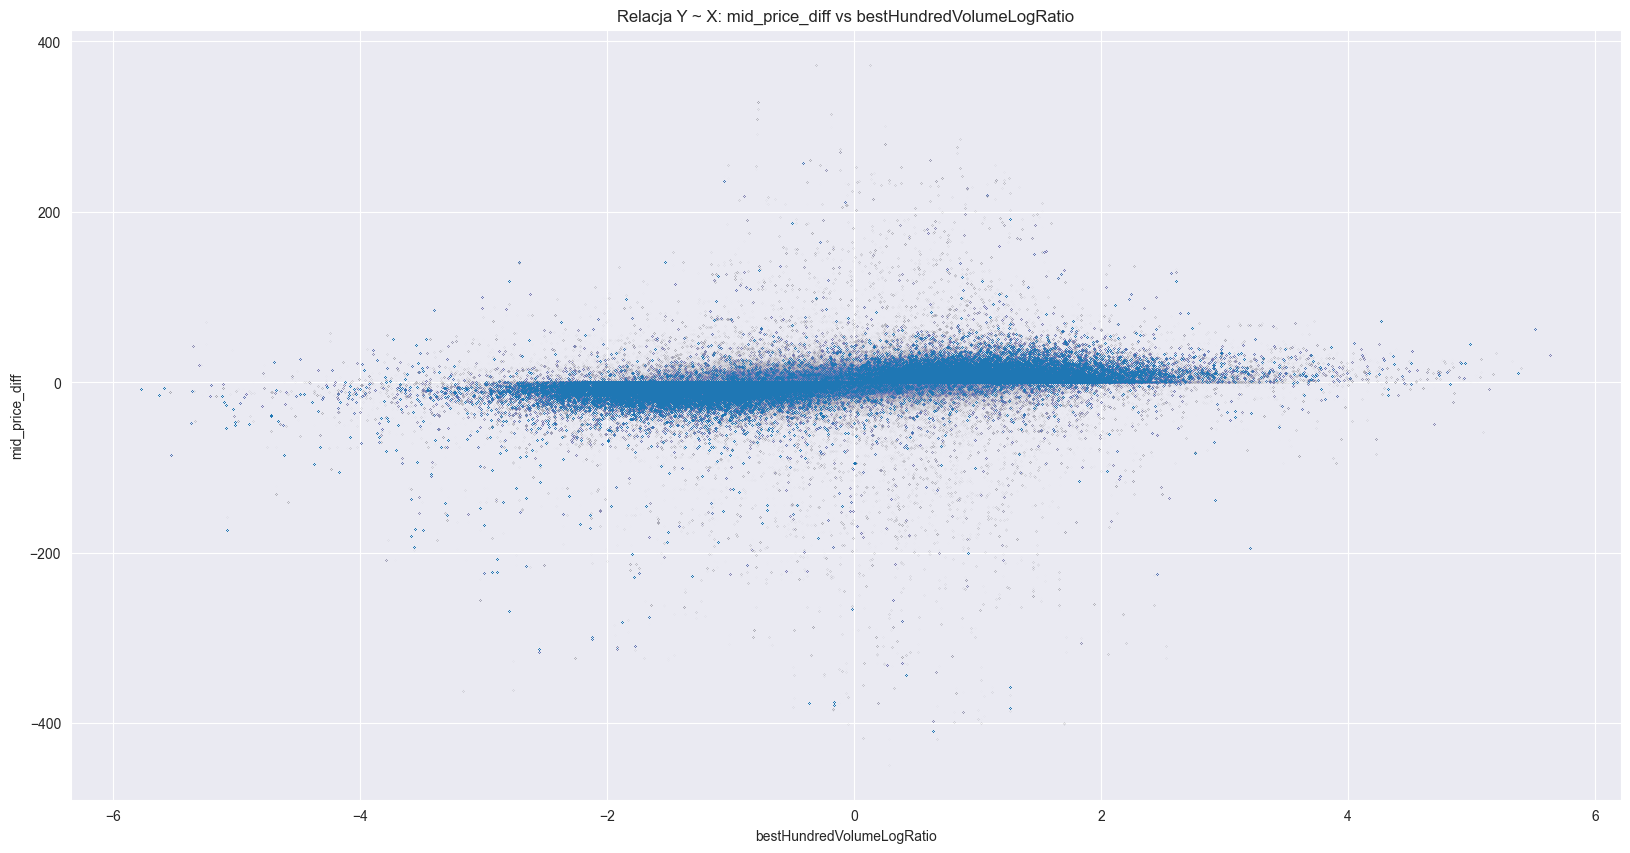

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

feature = 'bestHundredVolumeLogRatio'

plt.figure(figsize=(20, 10))
plt.scatter(
    main_ols_results["mid_price_diff"]['x_train'][feature],
    main_ols_results["mid_price_diff"]['y_train'],
    s=0.00001
)
plt.xlabel(feature)
plt.ylabel('mid_price_diff')
plt.title(f"Relacja Y ~ X: mid_price_diff vs {feature}")
plt.grid(True)
plt.show()

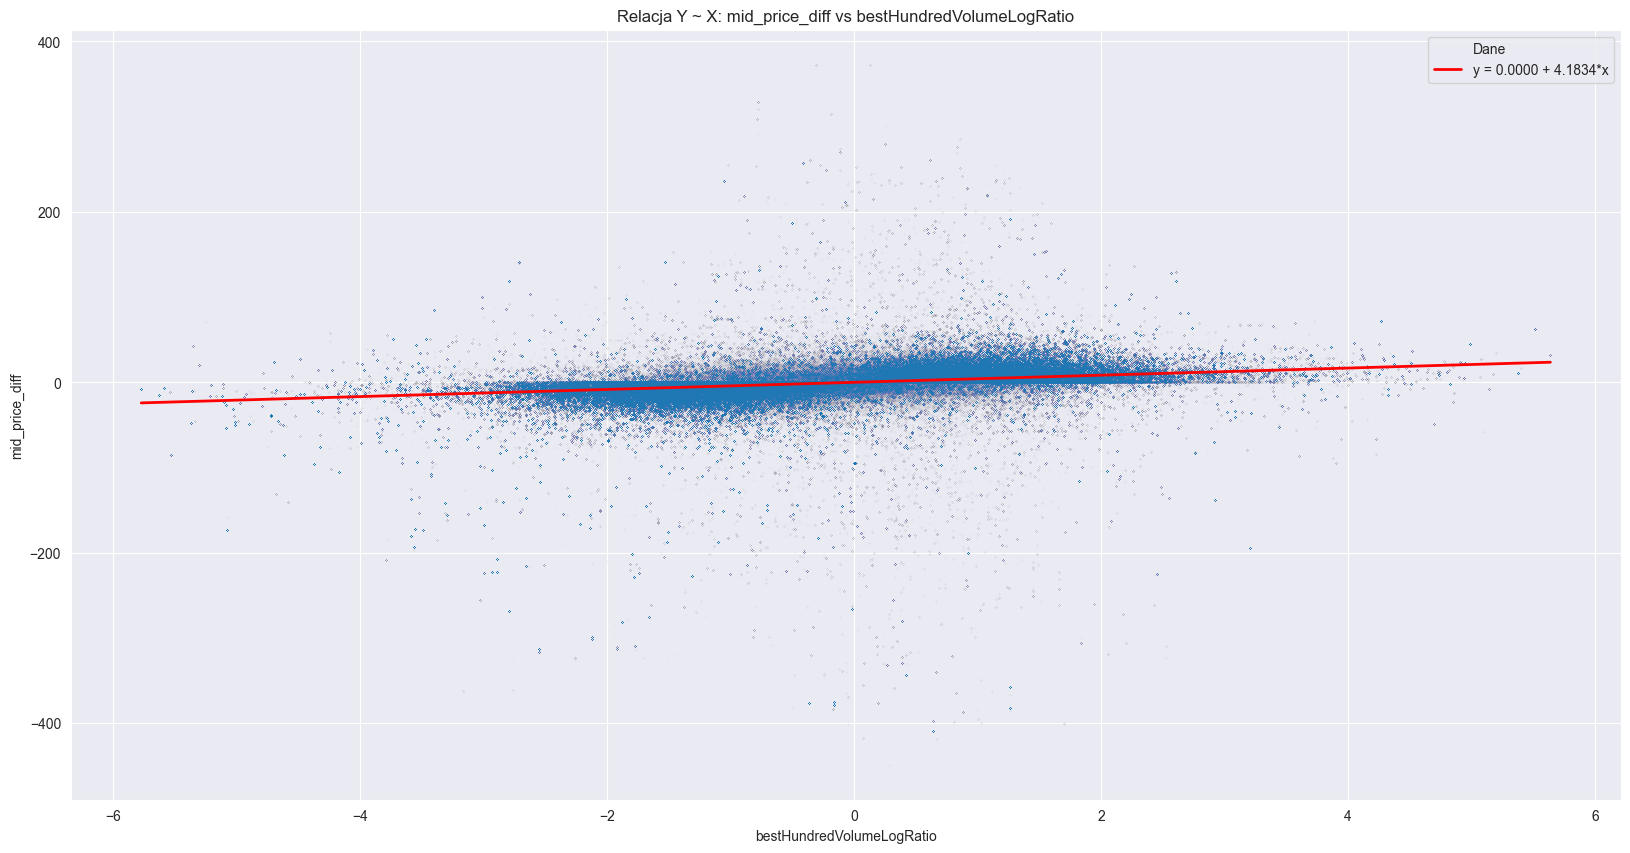

In [11]:
import matplotlib.pyplot as plt
import numpy as np

feature = 'bestHundredVolumeLogRatio'

intercept = 0
coef      = 4.1834

x_vals = main_ols_results["mid_price_diff"]['x_train'][feature]
y_vals = main_ols_results["mid_price_diff"]['y_train']

x_line = np.linspace(x_vals.min(), x_vals.max(), 500)
y_line = intercept + coef * x_line

plt.figure(figsize=(20, 10))
plt.scatter(x_vals, y_vals, s=0.00001, alpha=0.9, label="Dane")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {intercept:.4f} + {coef:.4f}*x")
plt.xlabel(feature)
plt.ylabel('mid_price_diff')
plt.title(f"Relacja Y ~ X: mid_price_diff vs {feature}")
plt.legend()
plt.grid(True)
plt.show()

# Correlation

In [9]:
from scipy.stats import pearsonr

def feature_correlations(x: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    results = []
    for col in features:
        r, pval = pearsonr(x[col], y)
        results.append({
            "feature": col,
            "pearson_r": r,
            "r2_single_feature": r ** 2,
            "p_value": pval
        })
    return pd.DataFrame(results).sort_values("r2_single_feature", ascending=False).reset_index(drop=True)


feature_correlations(main_ols_results["mid_price_diff"]["x_train"], main_ols_results["mid_price_diff"]["y_train"])

,feature,pearson_r,r2_single_feature,p_value
0,bestHundredVolumeLogRatio,0.305882,0.093564,0.0
1,bestVolumeLogRatio,0.295615,0.087388,0.0
2,volumeLogRatio,0.134800,0.018171,0.0


# Distribution

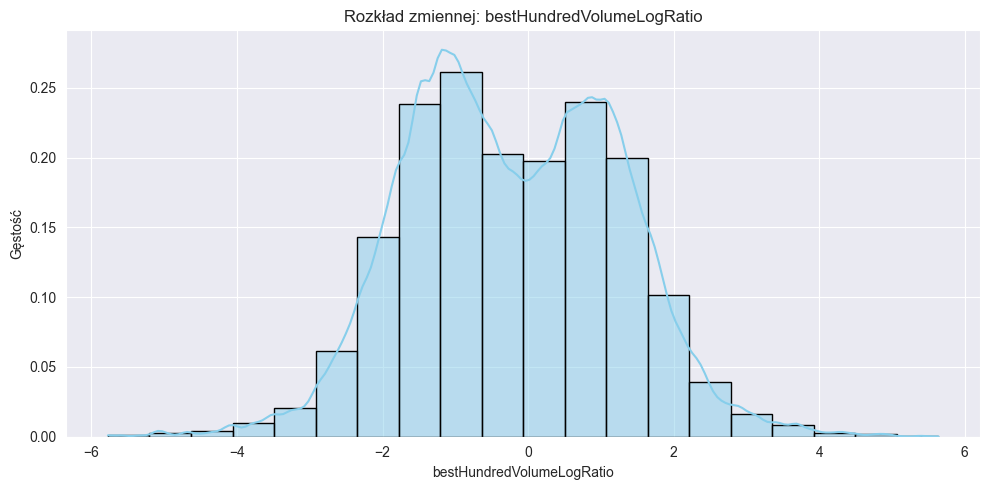

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

feature = 'bestHundredVolumeLogRatio'

plt.figure(figsize=(10, 5))
sns.histplot(
    main_ols_results["mid_price_diff"]["x_train"][f'{feature}'],
    kde=True,
    bins=20,
    stat='density',
    color='skyblue',
    edgecolor='black'
)

plt.title(f'Rozkład zmiennej: {feature}')
plt.xlabel(feature)
plt.ylabel('Gęstość')
plt.grid(True)
plt.tight_layout()
plt.show()